In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pypsa
import geopandas as gpd

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_2000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [3]:
buses = n.buses.loc[n.buses.carrier == 'AC'].index.unique()
data = pd.DataFrame(index=buses)

In [4]:
b = pd.read_csv(
    # Path.cwd().parent / 'results' / 'csvs_3_latest' / 'nodal_energy_balance.csv', index_col=[0,1,2,3], header=list(range(5))
    Path.cwd().parent / 'results' / 'csvs' / 'nodal_energy_balance.csv', index_col=[0,1,2,3], header=list(range(5))
    )
p = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'weighted_prices.csv', index_col=[0], header=list(range(5))
    )
c = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'nodal_capacity_factors.csv', index_col=[0,1,2], header=list(range(5))
    )

In [5]:
regions = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


In [6]:
def find_transition_column(
    df: pd.DataFrame,
    *,
    heuristic: str = "peak_slope",
    min_rel_change: float = 0.1,
    zero_tol: float = 0.0,
    direction: str = "upward",
) -> pd.Series:
    """
    For each row in df, return the column label where the *transition* occurs.

    Parameters
    ----------
    df : pd.DataFrame
        Rows to analyze.
    heuristic : str
        "peak_slope": pick the column where the extreme slope is maximal in the chosen direction.
        "first_nonzero": pick the first column where the row value becomes non-zero (> zero_tol).
    min_rel_change : float
        If row value range < min_rel_change * max(|row values|), treat as constant and return NaN.
    zero_tol : float
        Used for "first_nonzero".
    direction : str
        "upward" (default): look for maximal increase.
        "downward": look for maximal decrease.

    Returns
    -------
    pd.Series
        Index = df.index, values = column label or NaN.
    """
    if heuristic not in {"peak_slope", "first_nonzero"}:
        raise ValueError("heuristic must be one of {'peak_slope', 'first_nonzero'}")
    if direction not in {"upward", "downward"}:
        raise ValueError("direction must be one of {'upward', 'downward'}")

    cols = df.columns
    out = []

    for _, row in df.iterrows():
        x = row.to_numpy(dtype=float)

        # ── all-NaN row ──
        finite_mask = np.isfinite(x)
        if not np.any(finite_mask):
            out.append(np.nan)
            continue

        x_finite = x[finite_mask]
        row_max = np.max(x_finite)
        row_min = np.min(x_finite)
        row_range = row_max - row_min

        # ── constant-ish row ──
        # Use the absolute scale of the data so this works for negative,
        # positive, and mixed-sign rows alike.
        abs_scale = max(abs(row_max), abs(row_min))
        if abs_scale == 0 or row_range < min_rel_change * abs_scale:
            out.append(np.nan)
            continue

        # ── first_nonzero heuristic ──
        if heuristic == "first_nonzero":
            mask = np.isfinite(x) & (np.abs(x) > zero_tol)
            if not np.any(mask):
                out.append(np.nan)
            else:
                j = int(np.argmax(mask))
                out.append(cols[j])
            continue

        # ── peak_slope heuristic ──
        if len(x) < 2:
            out.append(np.nan)
            continue

        d = np.diff(x)

        # NaN diffs (from NaN gaps in the row) should be excluded,
        # not silently converted to +/-inf.
        valid = np.isfinite(d)

        if direction == "upward":
            candidates = np.where(valid & (d > 0), d, np.nan)
        else:
            candidates = np.where(valid & (d < 0), d, np.nan)

        if np.all(np.isnan(candidates)):
            out.append(np.nan)
            continue

        if direction == "upward":
            j = int(np.nanargmax(candidates))
        else:
            j = int(np.nanargmin(candidates))

        out.append(cols[j + 1])

    result = pd.Series(out, index=df.index, name="transition_column")
    return result.dropna()

In [7]:
b.columns = b.columns.get_level_values(-1)

<Axes: xlabel='wiggle'>

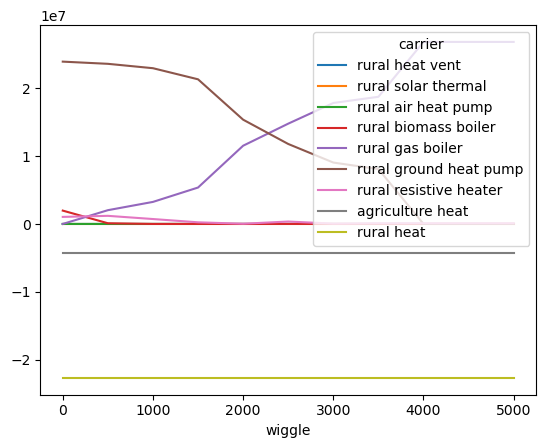

In [8]:
idx = pd.IndexSlice

ss = b.loc[idx[:,:,'DE0 0','rural heat']]
ss.index = ss.index.droplevel(0)
ss.T.plot()

In [9]:
def bus_carrier_transition_column(
    b, 
    bus_carrier='rural heat',
    carrier='rural gas boiler',
    direction='upward',
):
    """
    For each bus, find the transition column for the given carrier and bus_carrier.
    Adds the result as an integer column to the global `regions` DataFrame.

    Parameters
    ----------
    b : pd.DataFrame
        MultiIndexed DataFrame (multi-index: cluster, opt, location, bus_carrier, carrier)
    bus_carrier : str
        The spatial bus/carrier, e.g. 'rural heat', 'urban heat', etc.
    carrier : str
        The carrier to look for transitions, e.g. 'rural gas boiler'.
    direction : str
        Direction to search for transitions ('upward' or 'downward').
    region_col_name : str
        Name of the column to assign in the `regions` DataFrame.

    Returns
    -------
    pd.Series
        Series of transition columns (indexed by bus).
    """
    buses = b.index.get_level_values(2).unique()
    transitions = pd.Series(np.nan, index=buses)

    for bus in buses:
        try:
            ss = b.loc[idx[:, :, bus, bus_carrier]]
            ss.index = ss.index.droplevel(0)

            # Try finding the transition column
            value = find_transition_column(ss.loc[[carrier]], direction=direction)

            if value.empty:
                ss = ss.clip(lower=0)
                is_alot = (ss.loc[carrier].sum() / ss.sum().sum()) > 0.1

                if is_alot:
                    transitions.loc[bus] = ss.columns[0]
                else:
                    transitions.loc[bus] = ss.columns[-1]
            else:
                transitions.loc[bus] = value.iloc[0]

        except KeyError:
            continue

    transitions.dropna(inplace=True)
    return transitions.astype(int)


In [10]:
# Use function for 'rural heat' and 'rural gas boiler'
regions['rural ground heat pump'] = bus_carrier_transition_column(
    b=b, 
    bus_carrier='rural heat', 
    carrier='rural ground heat pump', 
    direction='downward', 
)

regions['decentral air heat pump'] = bus_carrier_transition_column(
    b=b, 
    bus_carrier='urban decentral heat', 
    carrier='urban decentral air heat pump', 
    direction='upward', 
)

regions['urban central air heat pump'] = bus_carrier_transition_column(
    b=b, 
    bus_carrier='urban central heat', 
    carrier='urban central air heat pump', 
    direction='upward', 
)

regions['rural biomass boiler'] = bus_carrier_transition_column(
    b=b, 
    bus_carrier='rural heat', 
    carrier='rural biomass boiler', 
    direction='downward', 
)

regions['decentral biomass boiler'] = bus_carrier_transition_column(
    b=b, 
    bus_carrier='urban decentral heat', 
    carrier='urban decentral biomass boiler', 
    direction='upward', 
)

regions['urban central solid biomass CHP'] = bus_carrier_transition_column(
    b=b, 
    bus_carrier='urban central heat', 
    carrier='urban central solid biomass CHP', 
    direction='upward', 
)

# regions['urban central gas CHP'] = bus_carrier_transition_column(
#     b=b, 
#     bus_carrier='urban central heat', 
#     carrier='urban central gas CHP', 
#     direction='upward', 
# )

/tmp/ipykernel_5854/336556973.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  transitions.loc[bus] = value.iloc[0]
/tmp/ipykernel_5854/336556973.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1500' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  transitions.loc[bus] = value.iloc[0]
/tmp/ipykernel_5854/336556973.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  transitions.loc[bus] = value.iloc[0]
/tmp/ipykernel_5854/336556973.py:49: FutureWarning: Setting an item of incompatible dtype is depreca

In [11]:
for carrier in ['onwind', 'solar']:

    gens = pd.Index(n.generators.loc[n.generators.carrier == carrier].bus)
    regions.loc[gens, carrier] = n.generators_t.p_max_pu.loc[:, gens + ' 0 ' + carrier].mean().values

In [12]:
b.loc[idx[:, :, :, 'urban central heat']].index.get_level_values(1).unique()

Index(['urban central heat vent', 'urban central solar thermal',
       'Fischer-Tropsch', 'H2 Electrolysis', 'Haber-Bosch', 'Sabatier',
       'methanolisation', 'urban central air heat pump',
       'urban central gas CHP', 'urban central gas boiler',
       'urban central resistive heater', 'urban central solid biomass CHP',
       'urban central solid biomass CHP CC', 'waste CHP',
       'urban central heat'],
      dtype='object', name='carrier')

In [13]:
regions.head()

,geometry,rural ground heat pump,decentral air heat pump,urban central air heat pump,rural biomass boiler,decentral biomass boiler,urban central solid biomass CHP,onwind,solar
name,,,,,,,,,
AL0 0,"MULTIPOLYGON (((19.44404 41.03374, 19.44275 41...",5000,1500,1000.0,2500,0,1000.0,0.044493,0.171923
AT0 0,"MULTIPOLYGON (((13.37242 46.57859, 13.36908 46...",4000,2500,4500.0,2500,4500,2000.0,0.136601,0.139419
BA0 0,"MULTIPOLYGON (((18.00855 42.75464, 18.00809 42...",4500,1500,4500.0,4000,1000,2000.0,0.045934,0.154138
BE0 0,"MULTIPOLYGON (((4.54113 49.96868, 4.53194 49.9...",4000,500,500.0,500,1000,1500.0,0.302484,0.111923
BG0 0,"POLYGON ((23.60586 41.37934, 23.5979 41.37818,...",4500,2000,2000.0,2000,1500,3000.0,0.121660,0.158226


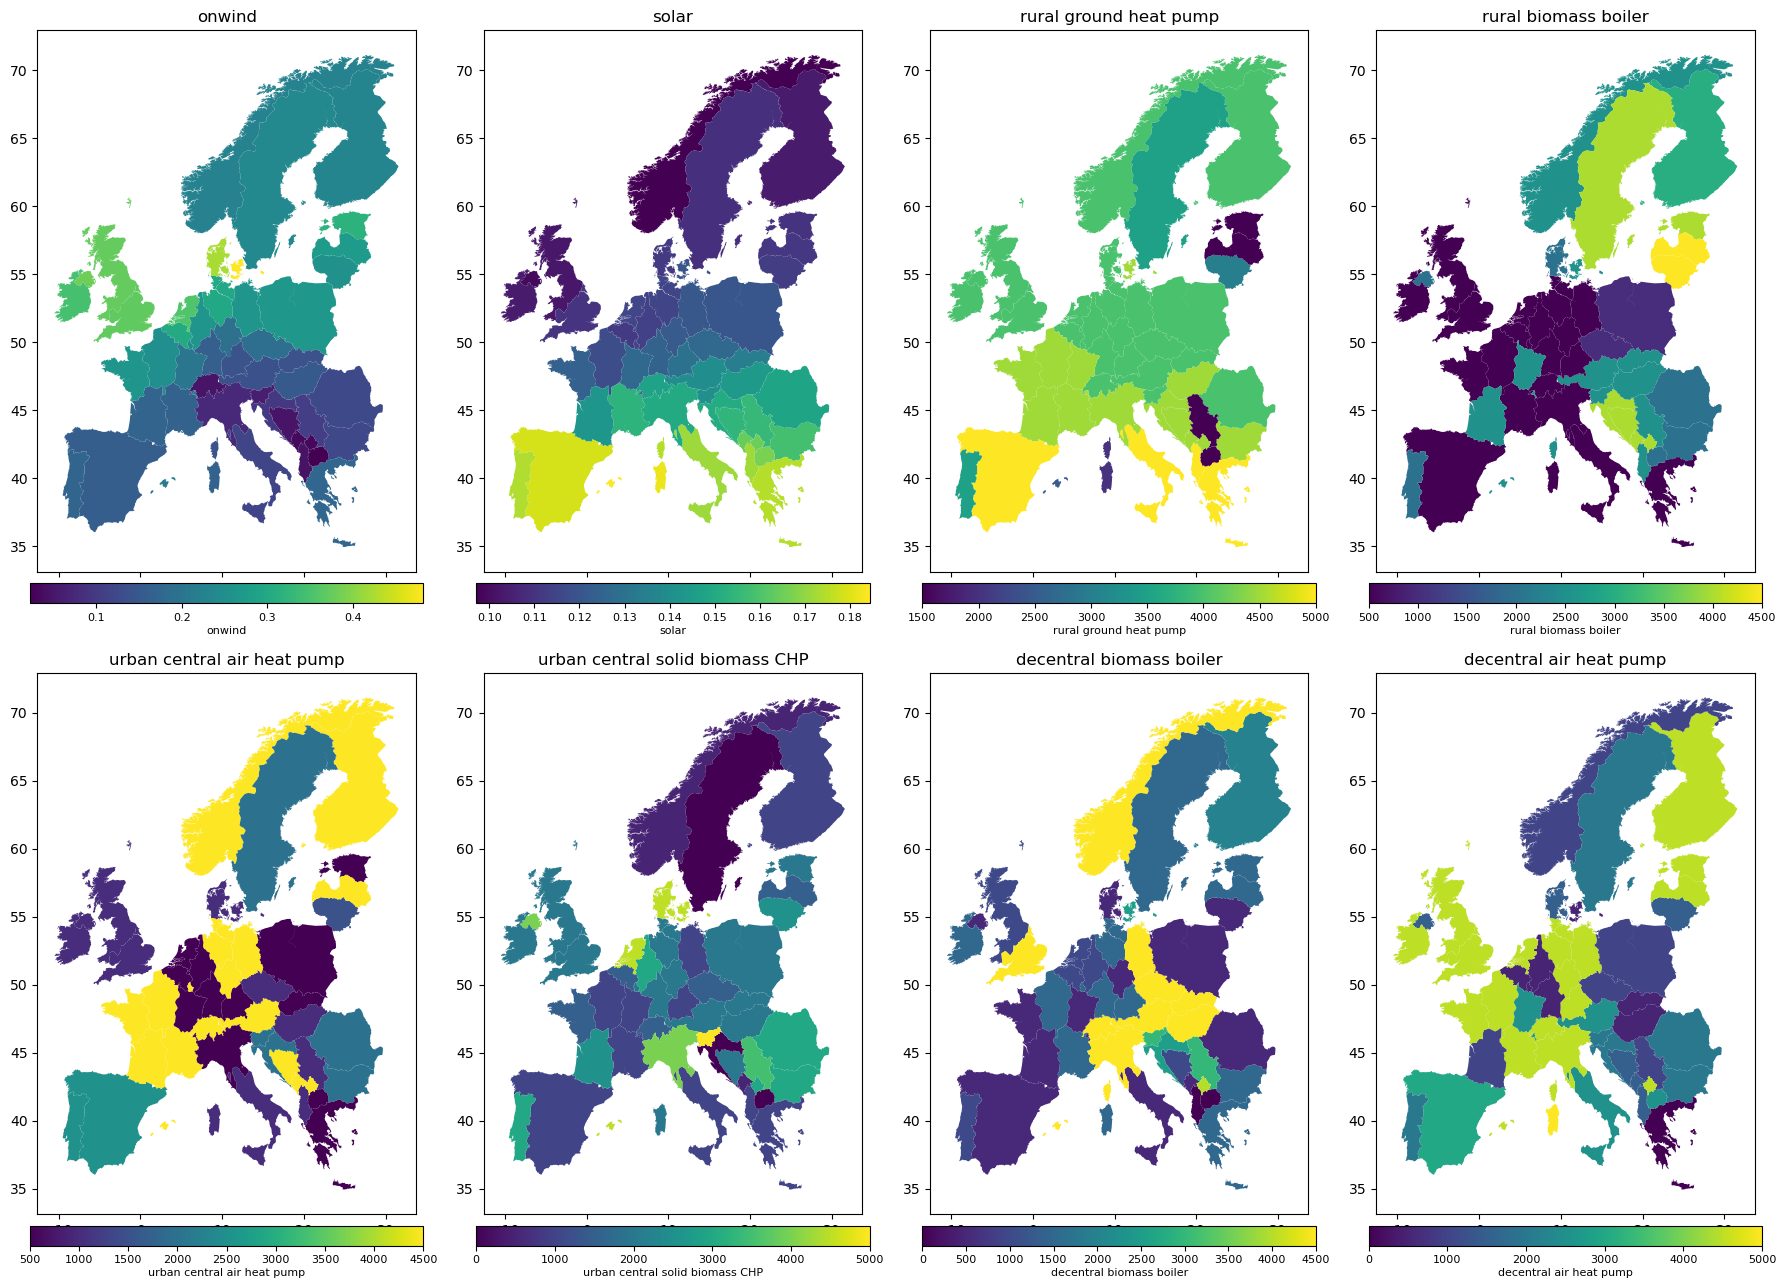

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 13))

columns = [
    'onwind',
    'solar',
    'rural ground heat pump',
    'rural biomass boiler',
    'urban central air heat pump',
    'urban central solid biomass CHP',
    'decentral biomass boiler',
    'decentral air heat pump',
]

import matplotlib as mpl

for ax, col in zip(axes.flatten(), columns):
    # Plot and grab the min/max for consistent colormap limits
    values = regions[col]
    vmin = values.min()
    vmax = values.max()
    # Using same vmin/vmax per plot (per column)
    plot = regions.plot(column=col, cmap='viridis', legend=False, ax=ax, vmin=vmin, vmax=vmax)
    ax.set_title(col)

    # Create colorbar with same normalization as plot
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.02)
    cbar.ax.tick_params(labelsize=8)
    cbar.ax.set_xlabel(col, fontsize=8, labelpad=2)

plt.tight_layout()


In [15]:
n.generators.carrier.unique()

array(['nuclear', 'offwind-ac', 'offwind-dc', 'solar', 'onwind',
       'offwind-float', 'solar-hsat', 'ror', 'gas', 'oil primary',
       'urban central heat vent', 'urban central solar thermal',
       'municipal solid waste', 'forest residues', 'industry wood',
       'landscape care', 'sewage sludge', 'manure and slurry', 'straw',
       'unsustainable biogas', 'unsustainable solid biomass',
       'unsustainable bioliquids', 'solid biomass', 'coal',
       'solar rooftop', 'rural heat vent', 'rural solar thermal',
       'urban decentral heat vent', 'urban decentral solar thermal',
       'co2-ets'], dtype=object)

In [16]:
n.generators.loc[n.generators.carrier == 'municipal solid waste', 'bus']

Generator
AL0 0 municipal solid waste                AL0 0 municipal solid waste
AT0 0 municipal solid waste                AT0 0 municipal solid waste
BA0 0 municipal solid waste                BA0 0 municipal solid waste
BE0 0 municipal solid waste                BE0 0 municipal solid waste
BG0 0 municipal solid waste                BG0 0 municipal solid waste
                                                      ...             
RS0 0 municipal solid waste transported    RS0 0 municipal solid waste
SE1 0 municipal solid waste transported    SE1 0 municipal solid waste
SI0 0 municipal solid waste transported    SI0 0 municipal solid waste
SK0 0 municipal solid waste transported    SK0 0 municipal solid waste
XK0 0 municipal solid waste transported    XK0 0 municipal solid waste
Name: bus, Length: 100, dtype: object

In [17]:
ss = b.loc[idx[:,:,'DE0 0','solid biomass']]
ss.index = ss.index.droplevel(0)

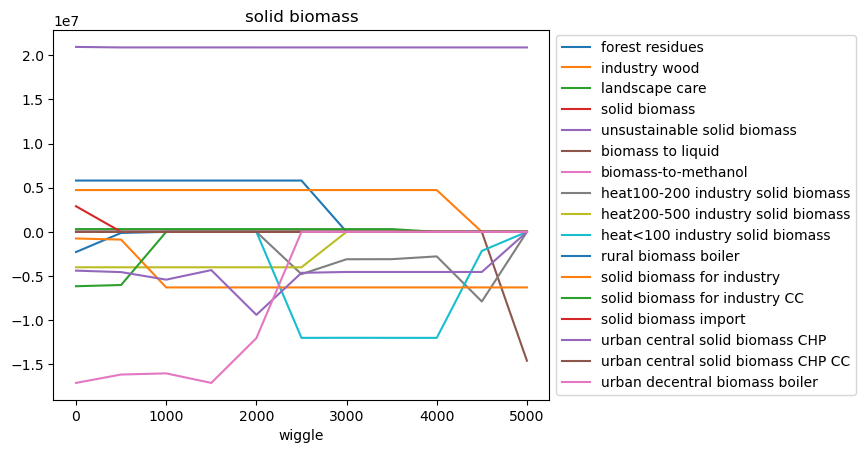

In [18]:
fig, ax = plt.subplots()
lines = ss.T.plot(ax=ax)
ax.set_title('solid biomass')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

In [19]:
def get_marginal_supply_cost(n, bus, carrier):

    if carrier in n.links.carrier.unique():
        mask = (n.links.carrier == carrier) & (n.links.index.str.contains(bus))
        assert mask.sum() <= 2, f"Expected one link for bus={bus} and carrier={carrier}, got {mask.sum()}"
        idx = n.links.index[mask][0]
        return n.links.loc[idx, 'marginal_cost']

    elif carrier in n.generators.carrier.unique():
        mask = (n.generators.carrier == carrier) & (n.generators.index.str.contains(bus))

        assert mask.sum() <= 2, f"Expected one generator for bus={bus} and carrier={carrier}, got {mask.sum()}"
        idx = n.generators.index[mask][0]
        return n.generators.loc[idx, 'marginal_cost']
    else:
        raise ValueError(f"Carrier {carrier} not found")

In [20]:
from tqdm import tqdm

# bus = 'DE0 0'

marginal_biomass_cost = pd.DataFrame(index=buses, columns=b.columns)

for bus in tqdm(buses):

    biomass_supply = b.loc[idx[:, :, bus, 'solid biomass']]
    biomass_supply = biomass_supply.loc[biomass_supply.sum(axis=1) > 0]

    marginal_supply_type = pd.Series(index=biomass_supply.columns, dtype=str)
    marginal_supply_cost = pd.Series(index=biomass_supply.columns, dtype=float)

    assert (sorted(biomass_supply.columns.astype(int)) == biomass_supply.columns.astype(int)).all()

    last = pd.Index([])

    for col in biomass_supply.columns[::-1]:
        curr = biomass_supply[col].mul(1e-3).round()
        curr.index = curr.index.droplevel(0)

        present = curr.index[curr > 0]

        if not last is None:
            present = present.union(last)

        if len(present) > 0:

            marginal_source = pd.Series(
                list(map(lambda x: get_marginal_supply_cost(n, bus, x), present)), 
                index=present
            ).idxmax()

            marginal_supply_type.loc[col] = marginal_source
            marginal_supply_cost.loc[col] = get_marginal_supply_cost(n, bus, marginal_source)

        else:
            marginal_supply_type.loc[col] = 'none'
            marginal_supply_cost.loc[col] = 0
        
        last = present.copy()
    
    marginal_biomass_cost.loc[bus] = marginal_supply_cost

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 20.95it/s]


<Axes: xlabel='wiggle'>

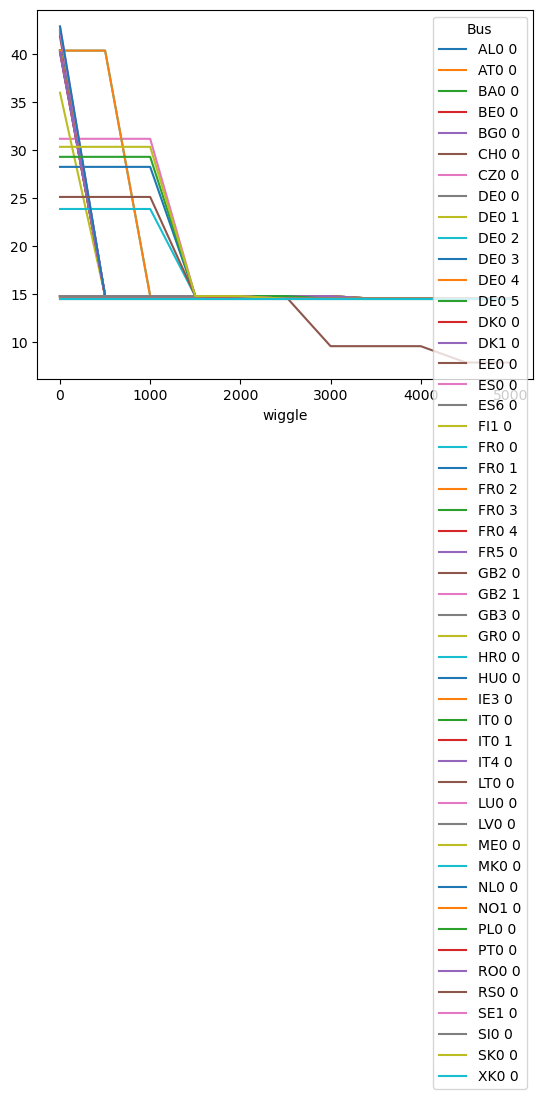

In [21]:
marginal_biomass_cost.T.plot()

##### Heat pump lcoes

In [22]:
n_low = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_0.nc'
)
n_med = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_2000.nc'
)
n_high = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_4000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_0.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_4000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [23]:
capex = n.statistics.capex(groupby=['bus', 'carrier', 'bus_carrier'])
opex = n.statistics.opex(groupby=['bus', 'carrier', 'bus_carrier'])

In [24]:
capex.loc[idx[:, 'DE0 0 gas']]

component  carrier                     bus_carrier
Link       Combined-Cycle Gas          gas            2.363974e+03
           Open-Cycle Gas              gas            5.778824e+07
           SMR                         gas            1.263898e+04
           gas DRI                     gas            1.288045e+03
           gas for industry CC         gas            1.895348e+03
           gas pipeline                gas            2.238337e+07
           heat100-200 industry gas    gas            8.322109e+01
           heat200-500 industry gas    gas            4.887576e+01
           heat<100 industry gas       gas            8.995074e+01
           heat>500 industry gas       gas            2.598430e+06
           rural gas boiler            gas            5.663807e+08
           urban central gas CHP       gas            5.165039e+07
           urban central gas boiler    gas            2.415029e+07
           urban decentral gas boiler  gas            1.288252e+09
Store      

In [25]:
from tqdm import tqdm

from itertools import product


lcohs = pd.DataFrame(index=pd.MultiIndex.from_product([buses, (carriers := [
                'urban decentral air heat pump',
                'rural ground heat pump',
                'urban central air heat pump',

                'rural biomass boiler',
                'urban decentral biomass boiler',
                'urban central solid biomass CHP',

                'rural gas boiler',
                'urban decentral gas boiler',
                'urban central gas CHP',
                'urban central gas boiler',
            ])
        ]), columns=[0, 2000, 4000])

demand_carriers = [
                'urban decentral heat',
                'rural heat',
                'urban central heat',

                'rural heat',
                'urban decentral heat',
                'urban central heat',

                'rural heat',
                'urban decentral heat',
                'urban central heat',
                'urban central heat',
                ]

fuel_carriers = [
    'low voltage',
    'low voltage',
    'low voltage',
    'solid biomass',
    'solid biomass',
    'solid biomass',
    'gas',
    'gas',
    'gas',
    'gas',
]


gas_consumptions = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
bus_majority_supply = pd.DataFrame(index=pd.MultiIndex.from_product([buses, set(demand_carriers)]), columns=gas_consumptions)

for wiggle in tqdm(gas_consumptions):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / f'base_s_50__168H-T-H-B-I-A-dist1_2030_free_{wiggle}.nc'
    )

    w = n.snapshot_weightings['generators']

    capex = n.statistics.capex(groupby=['bus', 'carrier', 'bus_carrier'])
    opex = n.statistics.opex(groupby=['bus', 'carrier', 'bus_carrier'])

    eb = n.statistics.energy_balance(
        aggregate_time=False,
        groupby=[
            'bus',
            'carrier',
            'bus_carrier'
            ]
        )
    
    for bus, demand in bus_majority_supply.index:

        try:
            bus_balance = eb.loc[idx[:, bus + ' ' + demand, :, :]].sum(axis=1)
            bus_balance.index = bus_balance.index.get_level_values(1)
            bus_majority_supply.loc[(bus, demand), wiggle] = bus_balance.idxmax()
        except KeyError:
            print(f"KeyError for bus={bus}, demand={demand}")
            continue

    for bus, (tech_carrier, demand_carrier, fuel) in product(
        buses, zip(carriers, demand_carriers, fuel_carriers)
        ):

        try:
            withdrawal = eb.loc[idx[
                'Link',
                bus + ' ' + fuel,
                tech_carrier,
                fuel
                ]].mul(w).mul(-1)
        except KeyError:
            print(f"KeyError for bus={bus}, tech_carrier={tech_carrier}, fuel={fuel}")
            continue

        fuel_cost = n.buses_t.marginal_price[bus + ' ' + fuel].mul(withdrawal).sum()

        delivered_heat = eb.loc[idx[
            'Link',
            bus + ' ' + demand_carrier,
            tech_carrier,
            demand_carrier
            ]].mul(w, axis=0).sum()
        
        o = opex.loc[idx['Link', bus + ' ' + fuel, tech_carrier, fuel]]
        c = capex.loc[idx['Link', bus + ' ' + fuel, tech_carrier, fuel]]

        assert isinstance(o, float)
        assert isinstance(c, float)
        assert isinstance(delivered_heat, float), delivered_heat

        if delivered_heat == 0.:
            lcoh = np.nan
        else:
            lcoh = (fuel_cost + c + o) / delivered_heat

        lcohs.loc[(bus, tech_carrier), wiggle] = lcoh

  0%|          | 0/9 [00:00<?, ?it/s]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_0.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


KeyError for bus=FR5 0, demand=urban central heat
KeyError for bus=FR5 0, tech_carrier=urban central air heat pump, fuel=low voltage
KeyError for bus=FR5 0, tech_carrier=urban central solid biomass CHP, fuel=solid biomass
KeyError for bus=FR5 0, tech_carrier=urban central gas CHP, fuel=gas
KeyError for bus=FR5 0, tech_carrier=urban central gas boiler, fuel=gas


 11%|█         | 1/9 [00:02<00:21,  2.66s/it]INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


KeyError for bus=FR5 0, demand=urban central heat
KeyError for bus=FR5 0, tech_carrier=urban central air heat pump, fuel=low voltage
KeyError for bus=FR5 0, tech_carrier=urban central solid biomass CHP, fuel=solid biomass
KeyError for bus=FR5 0, tech_carrier=urban central gas CHP, fuel=gas
KeyError for bus=FR5 0, tech_carrier=urban central gas boiler, fuel=gas


...

KeyError for bus=FR5 0, demand=urban central heat
KeyError for bus=FR5 0, tech_carrier=urban central air heat pump, fuel=low voltage
KeyError for bus=FR5 0, tech_carrier=urban central solid biomass CHP, fuel=solid biomass
KeyError for bus=FR5 0, tech_carrier=urban central gas CHP, fuel=gas
KeyError for bus=FR5 0, tech_carrier=urban central gas boiler, fuel=gas


 89%|████████▉ | 8/9 [00:24<00:03,  3.33s/it]INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_4000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


KeyError for bus=FR5 0, demand=urban central heat


100%|██████████| 9/9 [00:27<00:00,  3.11s/it]

KeyError for bus=FR5 0, tech_carrier=urban central air heat pump, fuel=low voltage
KeyError for bus=FR5 0, tech_carrier=urban central solid biomass CHP, fuel=solid biomass
KeyError for bus=FR5 0, tech_carrier=urban central gas CHP, fuel=gas
KeyError for bus=FR5 0, tech_carrier=urban central gas boiler, fuel=gas


In [26]:
import yaml

with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [32]:
def first_gas_col(row):
    for i, val in enumerate(row):
        if isinstance(val, str) and 'gas' in val:
            return i
    return len(row)  # Put rows with no 'gas' at the end

mode = 'rural'

ms = bus_majority_supply.loc[idx[:, mode + ' heat'], :]
ms.index = ms.index.get_level_values(0)
ms = ms.copy()
sorted_indices = ms.apply(first_gas_col, axis=1).sort_values().index
ms = ms.loc[sorted_indices]

In [28]:
tech_colors['rural ground heat pump'] = tech_colors['ground heat pump']
tech_colors['rural resistive heater'] = tech_colors['resistive heater']

/tmp/ipykernel_5854/3103377164.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss.sort_index(inplace=True, axis=1)


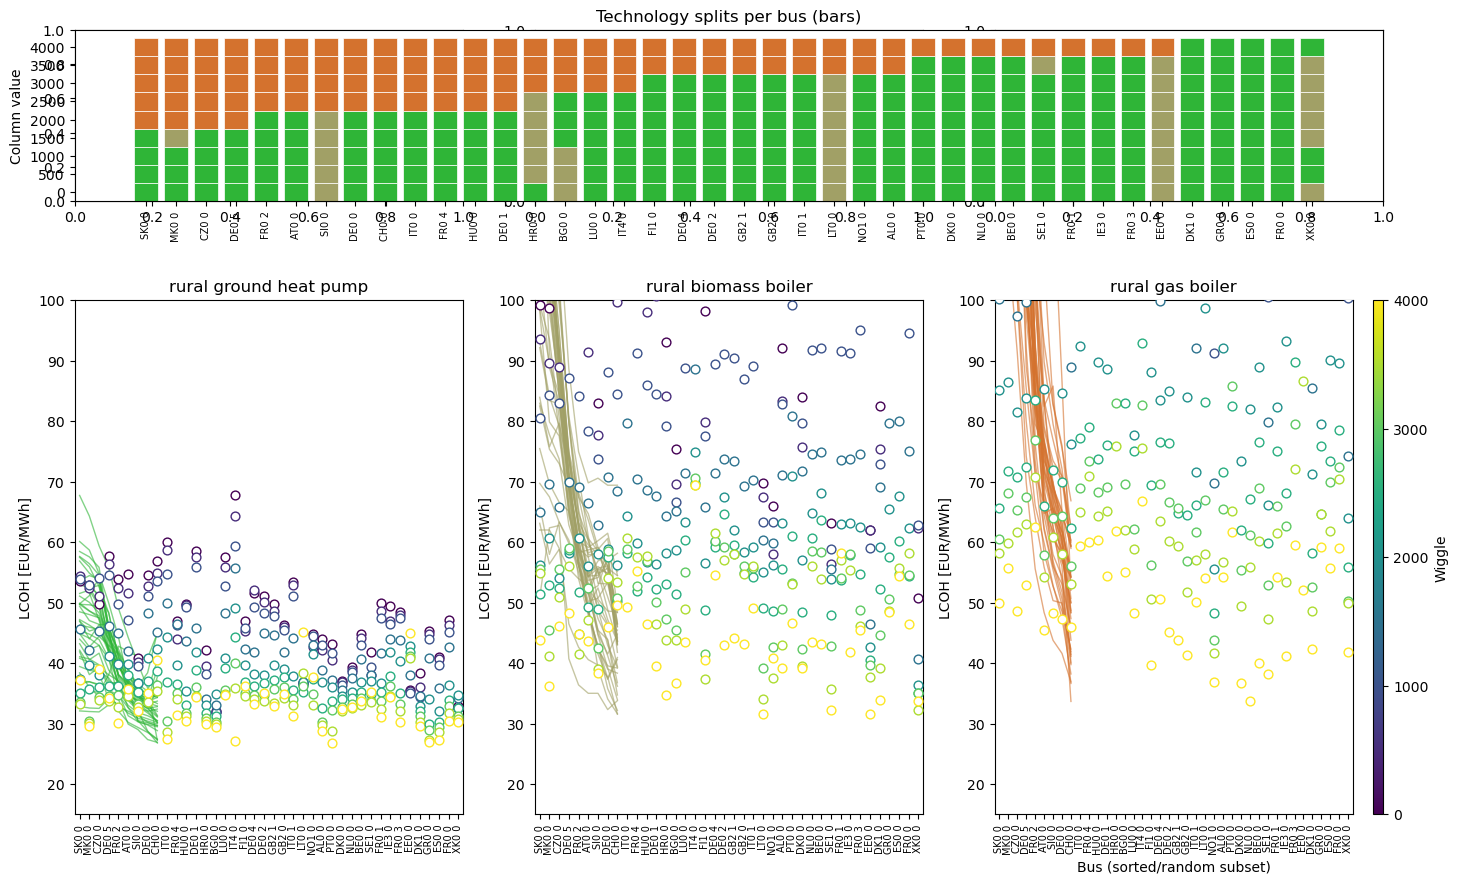

In [ ]:
import random

# Set the random subset size at the top of the script
RANDOM_BUS_SUBSET_SIZE = 40
random.seed(0)

# --- Sorting: by which column first contains 'gas' ---
def first_gas_col(row):
    for i, col in enumerate(ms.columns):
        if 'gas' in str(row[col]).lower():
            return i
    return len(ms.columns)  # no gas → sort to end

# Find the sorted busnames
ms_sorted_all = ms.loc[ms.apply(first_gas_col, axis=1).sort_values().index]

# Randomly select a subset of busnames (indices) after sorting
if len(ms_sorted_all) > RANDOM_BUS_SUBSET_SIZE:
    ms_sorted_subset_buses = random.sample(list(ms_sorted_all.index), RANDOM_BUS_SUBSET_SIZE)
else:
    ms_sorted_subset_buses = list(ms_sorted_all.index)

# Make sure selection is in correct order as in ms_sorted_all
ms_sorted_subset_buses = [b for b in ms_sorted_all.index if b in ms_sorted_subset_buses]
ms_sorted = ms_sorted_all.loc[ms_sorted_subset_buses]

# --- Plotting ---
n_tech = 3
fig, axes = plt.subplots(
    2, n_tech, figsize=(15, 9), 
    height_ratios=[1, n_tech]
)

# The top row: 1 big bar plot
ax_bar = plt.subplot2grid((2, n_tech), (0, 0), colspan=n_tech)
segment_height = 1  # uniform height per segment
n_segments = len(ms.columns)
for i, (busname, row) in enumerate(ms_sorted.iterrows()):
    bottom = - segment_height / 2
    for col in ms.columns:
        color = tech_colors[row[col]]
        ax_bar.bar(i, segment_height, bottom=bottom, color=color, width=0.8, edgecolor='white', linewidth=0.5)
        bottom += segment_height

ax_bar.set_xticks(range(len(ms_sorted)))
ax_bar.set_xticklabels(ms_sorted.index, rotation=90, fontsize=7)
ax_bar.set_ylabel('Column value')
ax_bar.set_yticks(list(range(n_segments)))
ax_bar.set_yticklabels(ms.columns)
ax_bar.set_title("Technology splits per bus (bars)")

# --- Prepare the lcoh data ---
ss = lcohs.loc[lcohs.index.get_level_values(1).str.contains(mode)]
ss.columns = ss.columns.astype(int)
ss.sort_index(inplace=True, axis=1)
sub_buses = ms_sorted.index
ss_subset = ss.loc[ss.index.get_level_values(0).isin(sub_buses)]

# There should be three technologies (rows per bus)
technologies = list(ss_subset.index.get_level_values(1).unique())
# To ensure consistent color mapping below
tech_color_map = {tech: tech_colors[tech] if tech in tech_colors else "grey" for tech in technologies}

# --- Split into three axes, one for each technology ---
edge_cmap = plt.cm.viridis
norm = plt.Normalize(ss.columns.min(), ss.columns.max())
edge_colors = [edge_cmap(norm(col)) for col in ss.columns]

# Collect data for colorbar only once
from mpl_toolkits.axes_grid1 import make_axes_locatable

xtick_positions = np.arange(len(ms_sorted.index))
xtick_labels = ms_sorted.index

for k, tech in enumerate(technologies):
    ax = axes[1, k]  # second row, column k

    # Build a (n_buses, n_columns) matrix: rows for buses, columns for wiggle values
    y_matrix = []
    for busname in ms_sorted.index:
        try:
            sss = ss_subset.loc[busname]
            if isinstance(sss, pd.Series):  # only one tech for this bus (unlikely)
                sss = pd.DataFrame([sss.values], columns=sss.index, index=[sss.name])
            if tech in sss.index:
                # Align this row to ss.columns order, fill with nan where missing
                lcoh_row = pd.Series(sss.loc[tech].values, index=sss.columns).reindex(ss.columns).values
            else:
                lcoh_row = np.full(len(ss.columns), np.nan)
        except KeyError:
            lcoh_row = np.full(len(ss.columns), np.nan)
        y_matrix.append(lcoh_row)

    y_matrix = np.array(y_matrix, dtype=float)  # shape: (n_buses, n_columns)
    n_buses = y_matrix.shape[0]
    n_wiggle = y_matrix.shape[1]

    # For consistent lines and markers, always use j (the wiggle index) for horizontal spread per bus
    for i in range(n_buses):
        yvals = y_matrix[i]
        valid = np.isfinite(yvals)
        if valid.any():
            # Scatter: edgecolor encodes wiggle, marker face is white
            for jcol, col in enumerate(ss.columns):
                if np.isfinite(yvals[jcol]):
                    ax.scatter(
                        [i],
                        [yvals[jcol]],
                        color="white",  # face color: white (or 'none' for hollow)
                        edgecolors=[edge_cmap(norm(col))],
                        s=40,
                        marker='o',
                        linewidths=1,
                        zorder=3,
                        label=f'wiggle={col}' if (i == 0 and jcol == 0 and k == 0) else ""
                    )
            ax.plot(
                np.arange(len(ss.columns)),
                yvals,
                color=tech_color_map[tech],
                linewidth=1,
                zorder=2,
                alpha=0.6,
            )

    # Set x axis: always show all bus indices and labels
    ax.set_xlim(-0.5, n_buses - 0.5)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=90, fontsize=7)

    ax.set_title(tech)
    ax.set_ylim(15, 100)
    ax.set_ylabel('LCOH [EUR/MWh]')

# Put colorbar next to the rightmost axis
sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(axes[1, -1])
cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = plt.colorbar(sm, cax=cax, label='Wiggle')
cbar.set_ticks(np.linspace(ss.columns.min(), ss.columns.max(), 5).astype(int))

axes[1, -1].set_xlabel("Bus (sorted/random subset)")

plt.tight_layout()
plt.show()

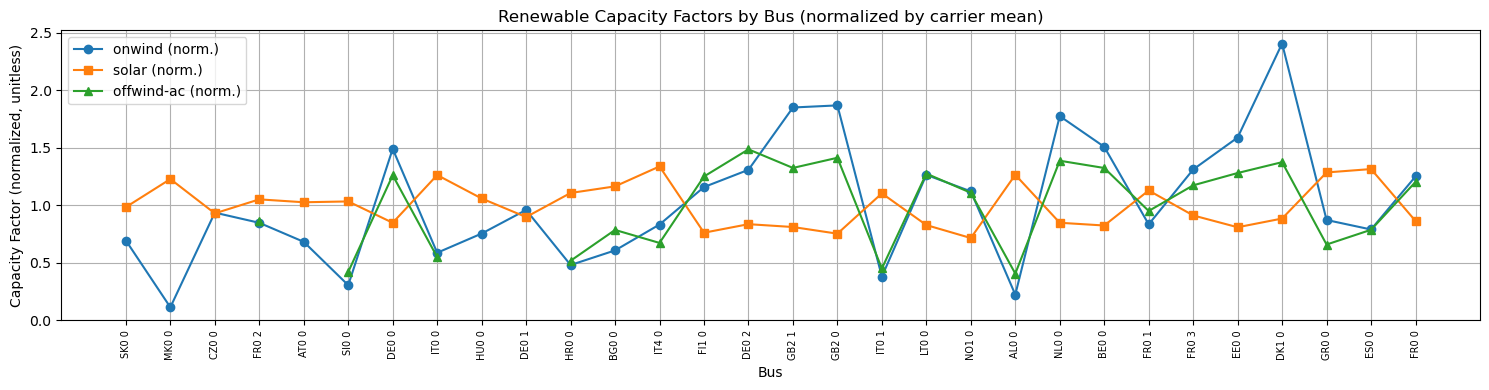

In [56]:
renewable_carriers = ['onwind', 'solar', 'offwind-ac']
cf_by_bus_and_carrier = {carrier: [] for carrier in renewable_carriers}
bus_labels = []

# Retrieve global average CF for each carrier for normalization
norm_factors = {}
for carrier in renewable_carriers:
    carrier_cols = [col for col in n.generators_t.p_max_pu.columns if col.endswith(carrier)]
    carrier_vals = []
    for col in carrier_cols:
        val = n.generators_t.p_max_pu[col].mean()
        if not np.isnan(val):
            carrier_vals.append(val)
    if carrier_vals:
        norm_factors[carrier] = np.nanmean(carrier_vals)
    else:
        norm_factors[carrier] = 1.0  # fallback if there's no data

for bus in ms_sorted.index:
    values_found = False
    for carrier in renewable_carriers:
        gen_name = f"{bus} 0 {carrier}"
        if gen_name in n.generators_t.p_max_pu.columns:
            cf = n.generators_t.p_max_pu[gen_name].mean()
            # Normalize the capacity factor by the mean for this carrier
            norm_cf = cf / norm_factors[carrier] if norm_factors[carrier] != 0 else np.nan
            cf_by_bus_and_carrier[carrier].append(norm_cf)
            values_found = True
        else:
            cf_by_bus_and_carrier[carrier].append(np.nan)
    bus_labels.append(bus)  # Keep all bus labels for xticks, even if all NaN

fig, ax = plt.subplots(1, 1, figsize=(15, 4))

for carrier, marker, color in zip(
    renewable_carriers, 
    ['o', 's', '^'], 
    ['tab:blue', 'tab:orange', 'tab:green']
):
    cfs = np.array(cf_by_bus_and_carrier[carrier])
    ax.plot(
        range(len(bus_labels)),
        cfs,
        label=carrier + " (norm.)",
        marker=marker,
        color=color,
        linestyle='-'
    )

ax.set_xticks(range(len(bus_labels)))
ax.set_xticklabels(bus_labels, rotation=90, fontsize=7)
ax.set_ylabel('Capacity Factor (normalized, unitless)')
ax.set_xlabel('Bus')
ax.set_title('Renewable Capacity Factors by Bus (normalized by carrier mean)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [52]:
cols = n.generators_t.p_max_pu.columns

cols[cols.str.contains('offwind')]

Index(['AL0 0 0 offwind-ac', 'AL0 0 0 offwind-float', 'BA0 0 0 offwind-ac',
       'BA0 0 0 offwind-float', 'BE0 0 0 offwind-ac', 'BE0 0 0 offwind-dc',
       'BE0 0 0 offwind-float', 'BG0 0 0 offwind-ac', 'BG0 0 0 offwind-dc',
       'BG0 0 0 offwind-float',
       ...
       'PT0 0 0 offwind-ac', 'PT0 0 0 offwind-float', 'RO0 0 0 offwind-ac',
       'RO0 0 0 offwind-dc', 'RO0 0 0 offwind-float', 'SE1 0 0 offwind-ac',
       'SE1 0 0 offwind-dc', 'SE1 0 0 offwind-float', 'SI0 0 0 offwind-ac',
       'SI0 0 0 offwind-float'],
      dtype='object', name='Generator', length=101)

In [140]:
stats.head()

Optimal Capacity  \
Generator AL0 0 AC Offshore Wind (AC)                 0.00743   
                   Offshore Wind (Floating)           0.00596   
                   Onshore Wind                     234.00068   
                   Run of River                      48.20000   
                   Solar                            294.53775   

                                             Installed Capacity        Supply  \
Generator AL0 0 AC Offshore Wind (AC)                       0.0       5.33387   
                   Offshore Wind (Floating)                 0.0       6.00200   
                   Onshore Wind                           234.0   85049.45260   
                   Run of River                            48.2  213361.88022   
                   Solar                                  294.5  392264.69315   

                                             Withdrawal  Energy Balance  \
Generator AL0 0 AC Offshore Wind (AC)               0.0         5.33387   
                   Offshore Wind (Floating)         0.0         6.00200   
                   Onshore Wind                     0.0     85049.45260   
                   Run of River                     0.0    213361.88022   
                   Solar                            0.0    392264.69315   

                                             Transmission  Capacity Factor  \
Generator AL0 0 AC Offshore Wind (AC)                 0.0         0.082100   
                   Offshore Wind (Floating)           0.0         0.115772   
                   Onshore Wind                       0.0         0.041491   
                   Run of River                       0.0         0.505319   
                   Solar                              0.0         0.152032   

                                             Curtailment  Capital Expenditure  \
Generator AL0 0 AC Offshore Wind (AC)            5.02773         1.497197e+03   
                   Offshore Wind (Floating)      4.85688         1.763078e+03   
                   Onshore Wind               7509.73729         2.707852e+07   
                   Run of River               2695.40125         1.485381e+07   
                   Solar                     51746.80168         1.542173e+07   

                                             Operational Expenditure  \
Generator AL0 0 AC Offshore Wind (AC)                        0.13410   
                   Offshore Wind (Floating)                  0.14423   
                   Onshore Wind                           2102.59134   
                   Run of River                           1996.20554   
                   Solar                                  7564.27250   

                                                  Revenue  Market Value  
Generator AL0 0 AC Offshore Wind (AC)        2.770503e+02     51.852459  
                   Offshore Wind (Floating)  2.859871e+02     47.318841  
                   Onshore Wind              4.435219e+06     52.148720  
                   Run of River              9.634777e+06     45.156972  
                   Solar                     1.521712e+07     38.792988

In [152]:
for bus in stats.index.unique(0):





Index(['AL0 0', 'AT0 0', 'BA0 0', 'BE0 0', 'BG0 0', 'CH0 0', 'CZ0 0', 'DE0 0',
       'DE0 1', 'DE0 2', 'DE0 3', 'DE0 4', 'DE0 5', 'DK0 0', 'DK1 0', 'EE0 0',
       'ES0 0', 'ES6 0', 'FI1 0', 'FR0 0', 'FR0 1', 'FR0 2', 'FR0 3', 'FR0 4',
       'FR5 0', 'GB2 0', 'GB2 1', 'GB3 0', 'GR0 0', 'HR0 0', 'HU0 0', 'IE3 0',
       'IT0 0', 'IT0 1', 'IT4 0', 'LT0 0', 'LU0 0', 'LV0 0', 'ME0 0', 'MK0 0',
       'NL0 0', 'NO1 0', 'PL0 0', 'PT0 0', 'RO0 0', 'RS0 0', 'SE1 0', 'SI0 0',
       'SK0 0', 'XK0 0'],
      dtype='object', name='Bus')

In [143]:
ss = stats.loc[idx[:, 'DE0 0 rural heat', :]]
ss = ss.loc[ss.sum(axis=1) > 0]

lcoe = ss[['Capital Expenditure', '']]

Optimal Capacity  \
Generator rural heat rural heat vent                  2.10470   
                     rural solar thermal              0.03301   
Link      rural heat rural air heat pump              0.00000   
                     rural biomass boiler             0.00000   
                     rural gas boiler                 0.00000   
                     rural ground heat pump           0.00000   
                     rural resistive heater           0.00000   
Load      rural heat agriculture heat                 0.00000   
                     rural heat                       0.00000   

                                             Installed Capacity        Supply  \
Generator rural heat rural heat vent                        0.0  0.000000e+00   
                     rural solar thermal                    0.0  6.052030e+00   
Link      rural heat rural air heat pump                    0.0  1.284870e+02   
                     rural biomass boiler                   0.0  6.482367e+02   
                     rural gas boiler                       0.0  1.151584e+07   
                     rural ground heat pump                 0.0  1.534833e+07   
                     rural resistive heater                 0.0  3.003215e+04   
Load      rural heat agriculture heat                       0.0  0.000000e+00   
                     rural heat                             0.0  0.000000e+00   

                                               Withdrawal  Energy Balance  \
Generator rural heat rural heat vent         4.011613e+02   -4.011613e+02   
                     rural solar thermal     0.000000e+00    6.052030e+00   
Link      rural heat rural air heat pump     0.000000e+00    1.284870e+02   
                     rural biomass boiler    0.000000e+00    6.482367e+02   
                     rural gas boiler        0.000000e+00    1.151584e+07   
                     rural ground heat pump  0.000000e+00    1.534833e+07   
                     rural resistive heater  0.000000e+00    3.003215e+04   
Load      rural heat agriculture heat        4.231325e+06   -4.231325e+06   
                     rural heat              2.266325e+07   -2.266325e+07   

                                             Transmission  Capacity Factor  \
Generator rural heat rural heat vent                  0.0         0.021756   
                     rural solar thermal              0.0         0.020903   
Link      rural heat rural air heat pump              0.0         0.000000   
                     rural biomass boiler             0.0         0.000000   
                     rural gas boiler                 0.0         0.000000   
                     rural ground heat pump           0.0         0.000000   
                     rural resistive heater           0.0         0.000000   
Load      rural heat agriculture heat                 0.0              NaN   
                     rural heat                       0.0              NaN   

                                             Curtailment  Capital Expenditure  \
Generator rural heat rural heat vent           401.16131              0.00000   
                     rural solar thermal         4.78750            898.19602   
Link      rural heat rural air heat pump         0.00000              0.00000   
                     rural biomass boiler        0.00000              0.00000   
                     rural gas boiler            0.00000              0.00000   
                     rural ground heat pump      0.00000              0.00000   
                     rural resistive heater      0.00000              0.00000   
Load      rural heat agriculture heat            0.00000              0.00000   
                     rural heat                  0.00000              0.00000   

                                             Operational Expenditure  \
Generator rural heat rural heat vent                         3.67389   
                     rural solar thermal                     0.06564   
Link

In [151]:
stats.loc[idx[:, :, :, 'rural ground heat pump']]

Optimal Capacity  Installed Capacity  \
Link AL0 0 low voltage low voltage          31.53211                 0.0   
     AL0 0 rural heat  rural heat            0.00000                 0.0   
     AT0 0 low voltage low voltage         569.11640                 0.0   
     AT0 0 rural heat  rural heat            0.00000                 0.0   
     BA0 0 low voltage low voltage          26.30380                 0.0   
...                                              ...                 ...   
     SI0 0 rural heat  rural heat            0.00000                 0.0   
     SK0 0 low voltage low voltage         108.95172                 0.0   
     SK0 0 rural heat  rural heat            0.00000                 0.0   
     XK0 0 low voltage low voltage           0.00842                 0.0   
     XK0 0 rural heat  rural heat            0.00000                 0.0   

                                          Supply    Withdrawal  \
Link AL0 0 low voltage low voltage  0.000000e+00  2.145122e+05   
     AL0 0 rural heat  rural heat   8.162547e+05  0.000000e+00   
     AT0 0 low voltage low voltage  0.000000e+00  4.304543e+06   
     AT0 0 rural heat  rural heat   1.461468e+07  0.000000e+00   
     BA0 0 low voltage low voltage  0.000000e+00  2.208038e+05   
...                                          ...           ...   
     SI0 0 rural heat  rural heat   1.800656e+06  0.000000e+00   
     SK0 0 low voltage low voltage  0.000000e+00  8.663198e+05   
     SK0 0 rural heat  rural heat   3.087999e+06  0.000000e+00   
     XK0 0 low voltage low voltage  0.000000e+00  6.437030e+01   
     XK0 0 rural heat  rural heat   2.378019e+02  0.000000e+00   

                                    Energy Balance  Transmission  \
Link AL0 0 low voltage low voltage   -2.145122e+05           0.0   
     AL0 0 rural heat  rural heat     8.162547e+05           0.0   
     AT0 0 low voltage low voltage   -4.304543e+06           0.0   
     AT0 0 rural heat  rural heat     1.461468e+07           0.0   
     BA0 0 low voltage low voltage   -2.208038e+05           0.0   
...                                            ...           ...   
     SI0 0 rural heat  rural heat     1.800656e+06           0.0   
     SK0 0 low voltage low voltage   -8.663198e+05           0.0   
     SK0 0 rural heat  rural heat     3.087999e+06           0.0   
     XK0 0 low voltage low voltage   -6.437030e+01           0.0   
     XK0 0 rural heat  rural heat     2.378019e+02           0.0   

                                    Capacity Factor  Curtailment  \
Link AL0 0 low voltage low voltage         0.776595          0.0   
     AL0 0 rural heat  rural heat          0.000000          0.0   
     AT0 0 low voltage low voltage         0.863420          0.0   
     AT0 0 rural heat  rural heat          0.000000          0.0   
     BA0 0 low voltage low voltage         0.958261          0.0   
...                                             ...          ...   
     SI0 0 rural heat  rural heat          0.000000          0.0   
     SK0 0 low voltage low voltage         0.907695          0.0   
     SK0 0 rural heat  rural heat          0.000000          0.0   
     XK0 0 low voltage low voltage         0.872922          0.0   
     XK0 0 rural heat  rural heat          0.000000          0.0   

                                    Capital Expenditure  \
Link AL0 0 low voltage low voltage         1.839840e+07   
     AL0 0 rural heat  rural heat          0.000000e+00   
     AT0 0 low voltage low voltage         3.320689e+08   
     AT0 0 rural heat  rural heat          0.000000e+00   
     BA0 0 low voltage low voltage         1.534778e+07   
...                                                 ...   
     SI0 0 rural heat  rural heat          0.000000e+00   
     SK0 0 low voltage low voltage         6.357132e+07   
     SK0 0 rural heat  rural heat          0.000000e+00   
     XK0 0 low voltage low voltage         4.911108e+03   
     XK0 0 rural heat  rural heat          0.00

In [150]:
index = stats.index.unique(3)
index[index.str.contains('heat pump')]

Index(['heat100-200 industry industrial heat pump high temperature',
       'heat<100 industry industrial heat pump medium temperature',
       'rural air heat pump', 'rural ground heat pump',
       'urban central air heat pump', 'urban decentral air heat pump'],
      dtype='object')